In [22]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    port=3306,
    user="root",
    password="Arpittiwari@12345678"
)

print("MySQL connected successfully!")

MySQL connected successfully!


# Statistical Data Analysis Using Python

## Task 5
Statistical Data Analysis using Python, Pandas, NumPy, and SciPy

In [20]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "pandas",
    "numpy",
    "matplotlib",
    "scipy",
    "openpyxl"
])

print("Installation completed!")
print("Python used by this notebook:", sys.executable)

Installation completed!
Python used by this notebook: c:\Users\arpit\OneDrive\Desktop\Task-6-SQL-Data-Analysis\.venv\Scripts\python.exe


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

print("All libraries imported successfully!")

All libraries imported successfully!


In [23]:
import os

os.makedirs("charts", exist_ok=True)
os.makedirs("reports", exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [24]:
import os

files = os.listdir()

print("Files available in current folder:")
for file in files:
    print(file)

Files available in current folder:
charts
reports
task6_sql_analysis.ipynb


In [27]:
df = pd.read_csv("../dataset/StudentsPerformance.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [28]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (1000, 8)

Column Names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [29]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [30]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [31]:
df = df.drop_duplicates()

print("Duplicates removed successfully!")
print("Current dataset shape:", df.shape)

Duplicates removed successfully!
Current dataset shape: (1000, 8)


In [32]:
print("Data Types:")
print(df.dtypes)

Data Types:
gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object


In [33]:
score_columns = [
    "math score",
    "reading score",
    "writing score"
]

for col in score_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Score columns converted to numeric successfully!")
print(df[score_columns].dtypes)

Score columns converted to numeric successfully!
math score       int64
reading score    int64
writing score    int64
dtype: object


In [34]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [35]:
print("Descriptive Statistics:")
df[score_columns].describe()

Descriptive Statistics:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [36]:
statistics_summary = pd.DataFrame({
    "Mean": df[score_columns].mean(),
    "Median": df[score_columns].median(),
    "Standard Deviation": df[score_columns].std(),
    "Minimum": df[score_columns].min(),
    "Maximum": df[score_columns].max()
})

statistics_summary

,Mean,Median,Standard Deviation,Minimum,Maximum
math score,66.089,66.0,15.163080,0,100
reading score,69.169,70.0,14.600192,17,100
writing score,68.054,69.0,15.195657,10,100


In [37]:
gender_analysis = df.groupby("gender")[score_columns].mean()

print("Average Scores by Gender:")
gender_analysis

Average Scores by Gender:


,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [38]:
test_prep_analysis = df.groupby("test preparation course")[score_columns].mean()

print("Average Scores by Test Preparation Course:")
test_prep_analysis

Average Scores by Test Preparation Course:


,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [39]:
parental_education_analysis = df.groupby(
    "parental level of education"
)[score_columns].mean().sort_values("math score", ascending=False)

print("Average Scores by Parental Level of Education:")
parental_education_analysis

Average Scores by Parental Level of Education:


,math score,reading score,writing score
parental level of education,,,
master's degree,69.745763,75.372881,75.677966
bachelor's degree,69.389831,73.000000,73.381356
associate's degree,67.882883,70.927928,69.896396
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268
high school,62.137755,64.704082,62.448980


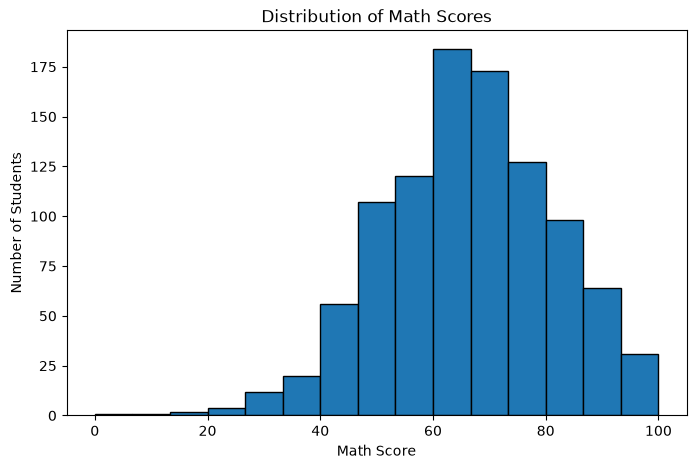

In [40]:
plt.figure(figsize=(8, 5))

plt.hist(df["math score"], bins=15, edgecolor="black")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")

plt.savefig("charts/math_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

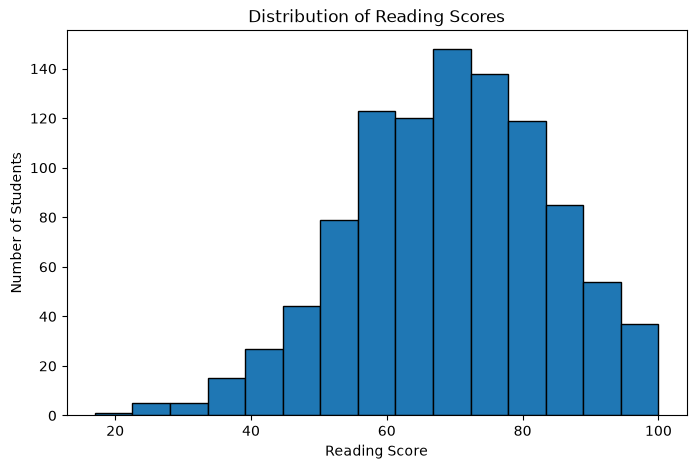

In [41]:
plt.figure(figsize=(8, 5))

plt.hist(df["reading score"], bins=15, edgecolor="black")

plt.title("Distribution of Reading Scores")
plt.xlabel("Reading Score")
plt.ylabel("Number of Students")

plt.savefig("charts/reading_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

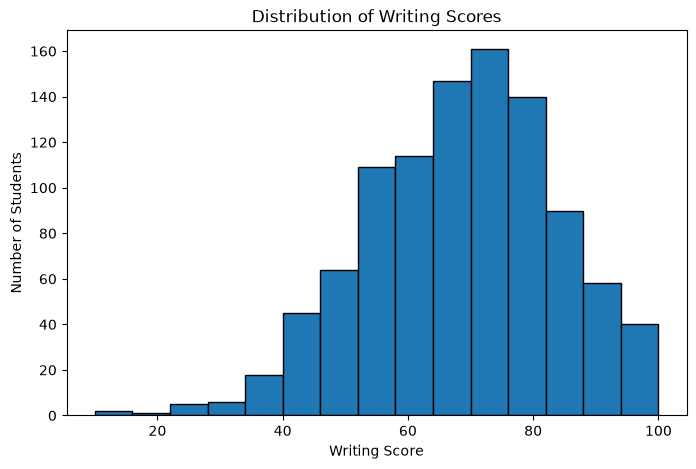

In [42]:
plt.figure(figsize=(8, 5))

plt.hist(df["writing score"], bins=15, edgecolor="black")

plt.title("Distribution of Writing Scores")
plt.xlabel("Writing Score")
plt.ylabel("Number of Students")

plt.savefig("charts/writing_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

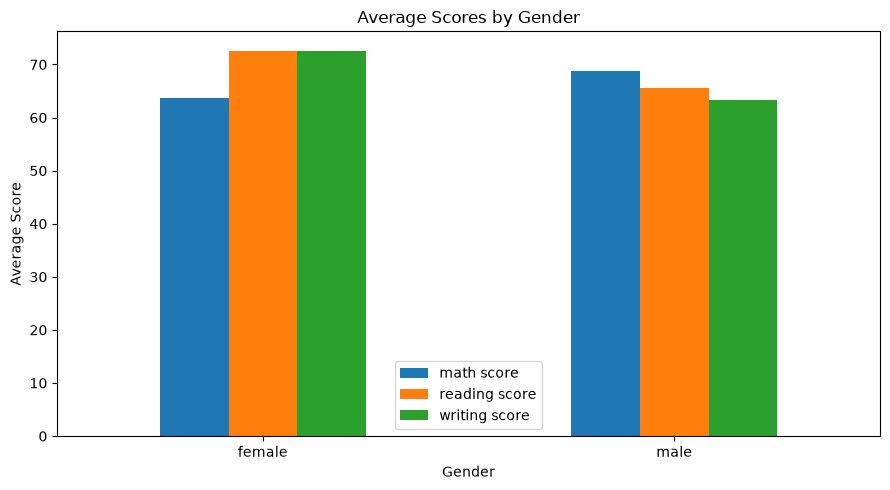

In [43]:
gender_analysis.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("charts/average_scores_by_gender.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

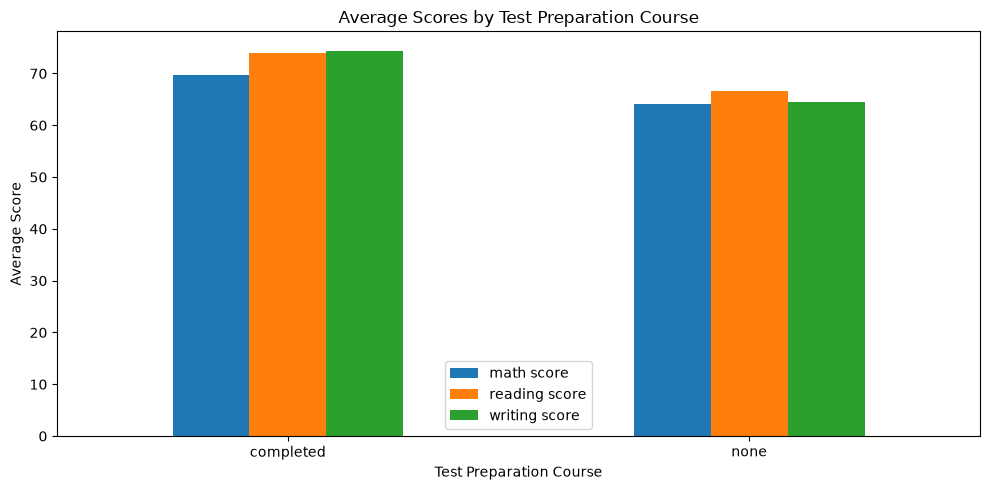

In [44]:
test_prep_analysis.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Scores by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("charts/test_preparation_scores.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [45]:
correlation_matrix = df[score_columns].corr()

print("Correlation Matrix:")
correlation_matrix

Correlation Matrix:


,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


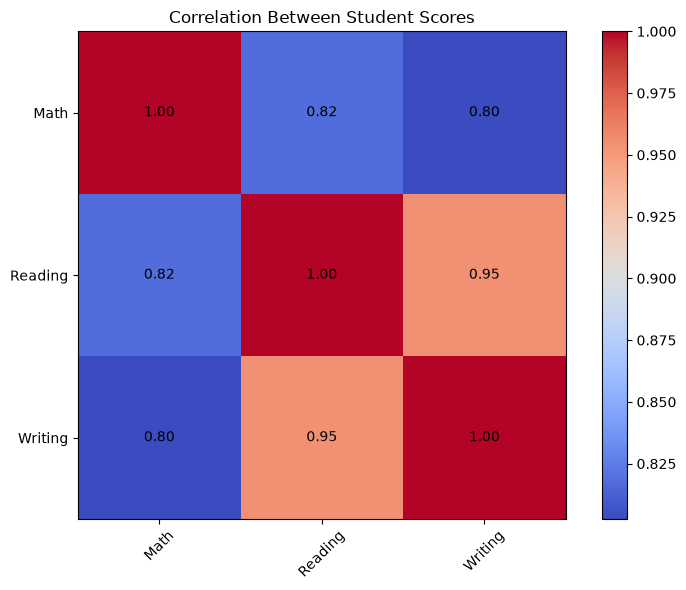

In [46]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(
    range(len(score_columns)),
    ["Math", "Reading", "Writing"],
    rotation=45
)

plt.yticks(
    range(len(score_columns)),
    ["Math", "Reading", "Writing"]
)

plt.title("Correlation Between Student Scores")

for i in range(len(score_columns)):
    for j in range(len(score_columns)):
        plt.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.savefig(
    "charts/score_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [47]:
r_value, p_value = stats.pearsonr(
    df["math score"],
    df["reading score"]
)

print("Pearson Correlation Test")
print("Correlation coefficient:", round(r_value, 4))
print("P-value:", round(p_value, 4))

Pearson Correlation Test
Correlation coefficient: 0.8176
P-value: 0.0


In [48]:
male_math = df[df["gender"] == "male"]["math score"]
female_math = df[df["gender"] == "female"]["math score"]

t_stat, p_value = stats.ttest_ind(
    male_math,
    female_math,
    equal_var=False
)

print("Independent T-Test: Male vs Female Math Scores")
print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

Independent T-Test: Male vs Female Math Scores
T-statistic: 5.398
P-value: 0.0


In [49]:
completed = df[
    df["test preparation course"] == "completed"
]["math score"]

none = df[
    df["test preparation course"] == "none"
]["math score"]

t_stat, p_value = stats.ttest_ind(
    completed,
    none,
    equal_var=False
)

print("T-Test: Test Preparation Course vs Math Score")
print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

T-Test: Test Preparation Course vs Math Score
T-statistic: 5.787
P-value: 0.0


In [50]:
alpha = 0.05

print("Significance Level:", alpha)

if p_value < alpha:
    print("Result: Statistically significant difference found.")
else:
    print("Result: No statistically significant difference found.")

Significance Level: 0.05
Result: Statistically significant difference found.


In [51]:
groups = [
    group["math score"].values
    for _, group in df.groupby("parental level of education")
]

anova_stat, anova_p = stats.f_oneway(*groups)

print("One-Way ANOVA: Parental Education vs Math Score")
print("F-statistic:", round(anova_stat, 4))
print("P-value:", round(anova_p, 4))

One-Way ANOVA: Parental Education vs Math Score
F-statistic: 6.5216
P-value: 0.0


In [52]:
alpha = 0.05

if anova_p < alpha:
    print("Result: There is a statistically significant difference between the groups.")
else:
    print("Result: There is no statistically significant difference between the groups.")

Result: There is a statistically significant difference between the groups.


In [53]:
distribution_analysis = pd.DataFrame({
    "Skewness": df[score_columns].skew(),
    "Kurtosis": df[score_columns].kurtosis()
})

print("Distribution Analysis:")
distribution_analysis

Distribution Analysis:


,Skewness,Kurtosis
math score,-0.278935,0.274964
reading score,-0.259105,-0.068265
writing score,-0.289444,-0.033365


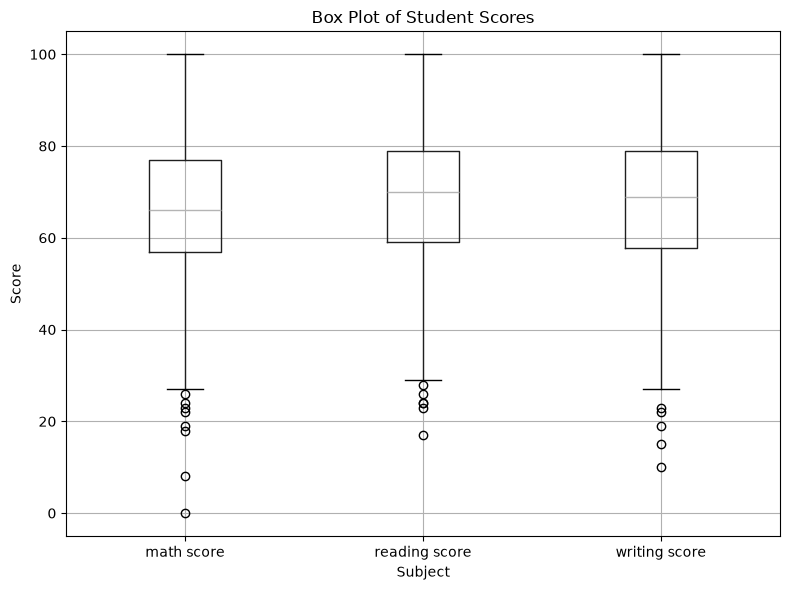

In [54]:
plt.figure(figsize=(8, 6))

df[score_columns].boxplot()

plt.title("Box Plot of Student Scores")
plt.xlabel("Subject")
plt.ylabel("Score")

plt.tight_layout()
plt.savefig(
    "charts/student_scores_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

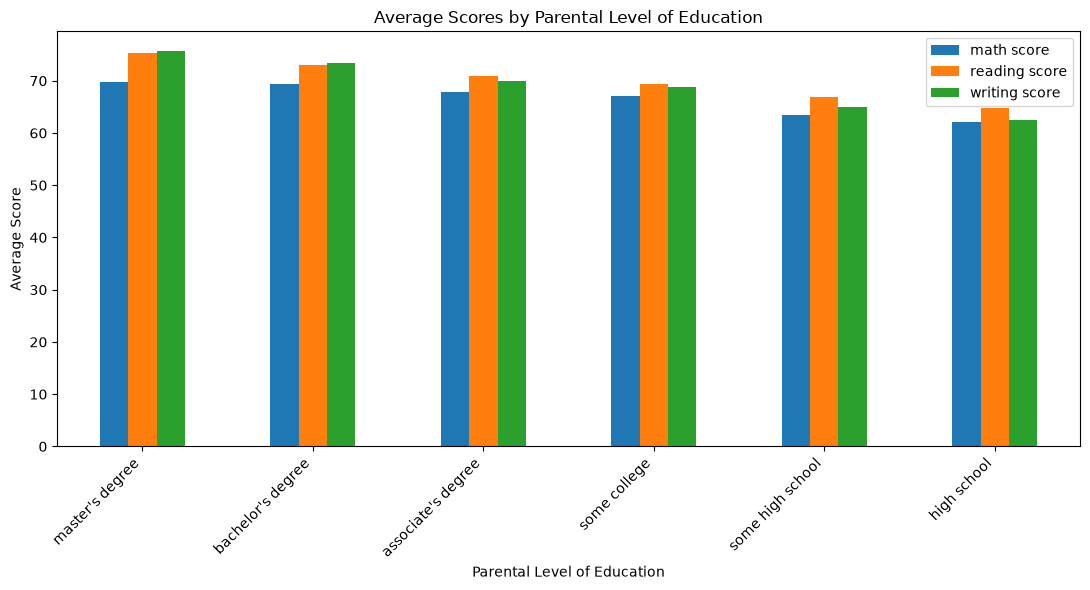

In [55]:
parental_education_analysis.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Average Scores by Parental Level of Education")
plt.xlabel("Parental Level of Education")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(
    "charts/parental_education_scores.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [56]:
lunch_analysis = df.groupby("lunch")[score_columns].mean()

print("Average Scores by Lunch Type:")
lunch_analysis

Average Scores by Lunch Type:


,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


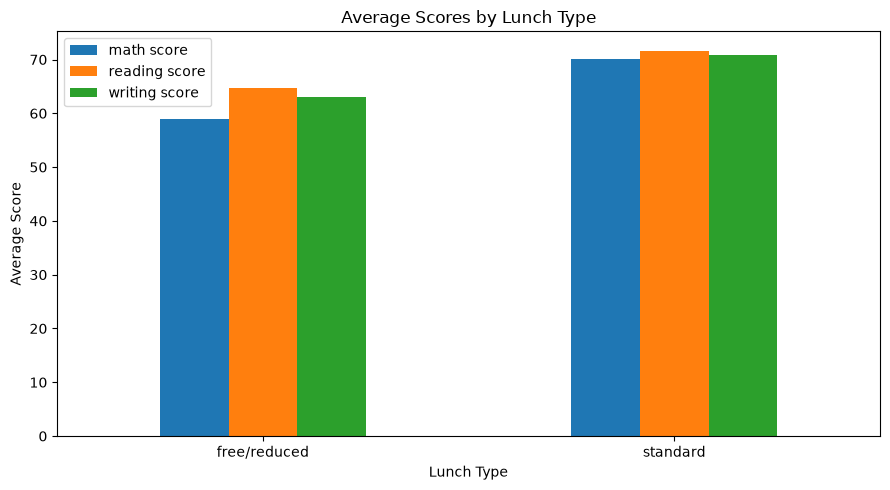

In [57]:
lunch_analysis.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Scores by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "charts/average_scores_by_lunch.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [58]:
test_prep_counts = df["test preparation course"].value_counts()

print("Test Preparation Course Distribution:")
print(test_prep_counts)

Test Preparation Course Distribution:
test preparation course
none         642
completed    358
Name: count, dtype: int64


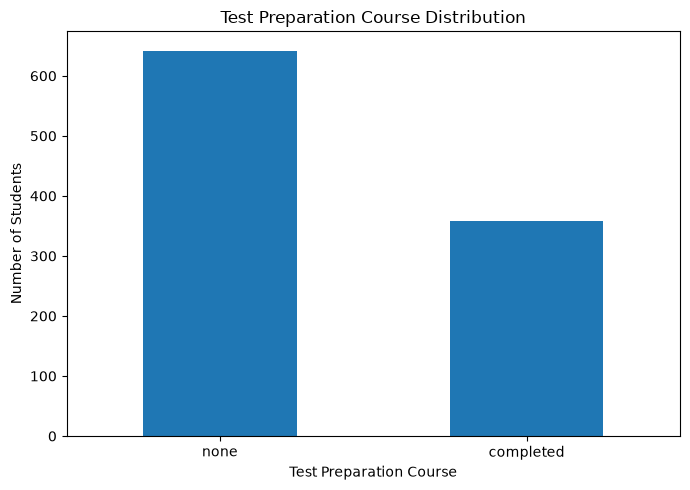

In [59]:
plt.figure(figsize=(7, 5))

test_prep_counts.plot(
    kind="bar"
)

plt.title("Test Preparation Course Distribution")
plt.xlabel("Test Preparation Course")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "charts/test_preparation_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [60]:
gender_counts = df["gender"].value_counts()

print("Gender Distribution:")
print(gender_counts)

Gender Distribution:
gender
female    518
male      482
Name: count, dtype: int64


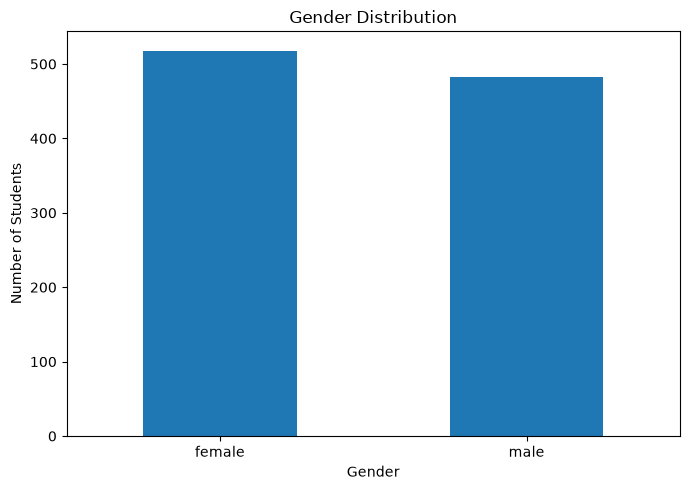

In [61]:
plt.figure(figsize=(7, 5))

gender_counts.plot(
    kind="bar"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [62]:
overall_average = df[score_columns].mean()

print("Overall Average Scores:")
print(overall_average.round(2))

Overall Average Scores:
math score       66.09
reading score    69.17
writing score    68.05
dtype: float64


In [63]:
df["overall score"] = df[score_columns].mean(axis=1)

print("Overall score calculated successfully!")
df[["math score", "reading score", "writing score", "overall score"]].head()

Overall score calculated successfully!


,math score,reading score,writing score,overall score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


In [64]:
top_students = df.nlargest(10, "overall score")

print("Top 10 Students by Overall Score:")
top_students[
    ["gender", "math score", "reading score", "writing score", "overall score"]
]

Top 10 Students by Overall Score:


,gender,math score,reading score,writing score,overall score
458,female,100,100,100,100.000000
916,male,100,100,100,100.000000
962,female,100,100,100,100.000000
114,female,99,100,100,99.666667
179,female,97,100,100,99.000000
712,female,98,100,99,99.000000
165,female,96,100,100,98.666667
625,male,100,97,99,98.666667
149,male,100,100,93,97.666667
685,female,94,99,100,97.666667


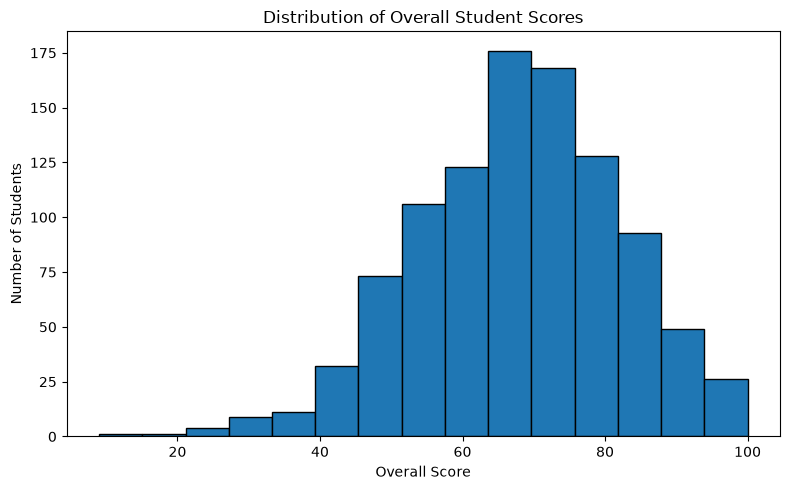

In [65]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["overall score"],
    bins=15,
    edgecolor="black"
)

plt.title("Distribution of Overall Student Scores")
plt.xlabel("Overall Score")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.savefig(
    "charts/overall_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

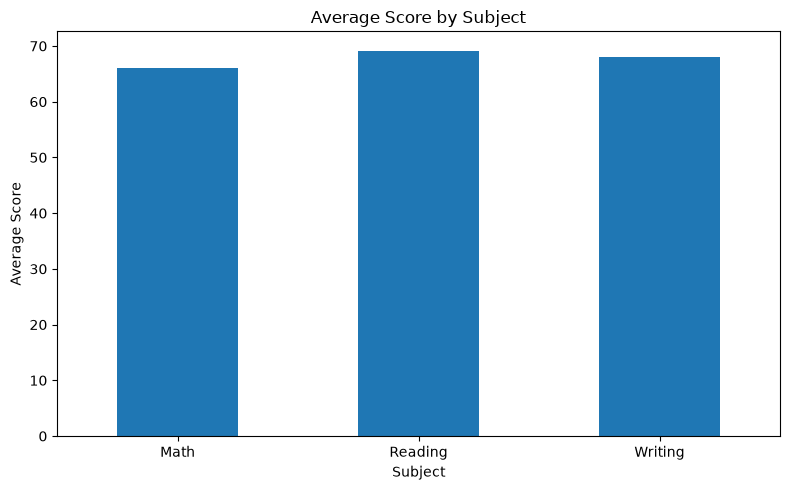

In [66]:
subject_averages = df[score_columns].mean()

plt.figure(figsize=(8, 5))

subject_averages.plot(kind="bar")

plt.title("Average Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.xticks(
    range(3),
    ["Math", "Reading", "Writing"],
    rotation=0
)

plt.tight_layout()
plt.savefig(
    "charts/subject_average_scores.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [67]:
df.to_csv(
    "../dataset/cleaned_students_performance.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [68]:
best_subject = overall_average.idxmax()
best_score = overall_average.max()

print("Best Performing Subject:", best_subject)
print("Average Score:", round(best_score, 2))

Best Performing Subject: reading score
Average Score: 69.17


In [69]:
lowest_subject = overall_average.idxmin()
lowest_score = overall_average.min()

print("Lowest Performing Subject:", lowest_subject)
print("Average Score:", round(lowest_score, 2))

Lowest Performing Subject: math score
Average Score: 66.09


In [70]:
gender_comparison = df.groupby("gender")["overall score"].mean()

print("Overall Performance by Gender:")
print(gender_comparison.round(2))

Overall Performance by Gender:
gender
female    69.57
male      65.84
Name: overall score, dtype: float64


In [71]:
preparation_comparison = df.groupby(
    "test preparation course"
)["overall score"].mean()

print("Overall Performance by Test Preparation Course:")
print(preparation_comparison.round(2))

Overall Performance by Test Preparation Course:
test preparation course
completed    72.67
none         65.04
Name: overall score, dtype: float64


In [72]:
print("=" * 60)
print("FINAL STATISTICAL FINDINGS")
print("=" * 60)

print(f"\n1. Best performing subject: {best_subject}")
print(f"   Average score: {best_score:.2f}")

print(f"\n2. Lowest performing subject: {lowest_subject}")
print(f"   Average score: {lowest_score:.2f}")

print("\n3. Overall performance by gender:")
print(gender_comparison.round(2))

print("\n4. Overall performance by test preparation:")
print(preparation_comparison.round(2))

print("\n5. Math-Reading correlation:")
print(f"   Correlation coefficient: {r_value:.4f}")
print(f"   P-value: {p_value:.4f}")

print("\n6. Parental education ANOVA:")
print(f"   F-statistic: {anova_stat:.4f}")
print(f"   P-value: {anova_p:.4f}")

FINAL STATISTICAL FINDINGS

1. Best performing subject: reading score
   Average score: 69.17

2. Lowest performing subject: math score
   Average score: 66.09

3. Overall performance by gender:
gender
female    69.57
male      65.84
Name: overall score, dtype: float64

4. Overall performance by test preparation:
test preparation course
completed    72.67
none         65.04
Name: overall score, dtype: float64

5. Math-Reading correlation:
   Correlation coefficient: 0.8176
   P-value: 0.0000

6. Parental education ANOVA:
   F-statistic: 6.5216
   P-value: 0.0000


In [73]:
statistics_summary.to_csv(
    "reports/statistical_summary.csv"
)

print("Statistical summary saved successfully!")

Statistical summary saved successfully!


In [74]:
correlation_matrix.to_csv(
    "reports/correlation_matrix.csv"
)

print("Correlation matrix saved successfully!")

Correlation matrix saved successfully!


In [75]:
gender_analysis.to_csv(
    "reports/gender_analysis.csv"
)

print("Gender analysis saved successfully!")

Gender analysis saved successfully!


In [76]:
test_prep_analysis.to_csv(
    "reports/test_preparation_analysis.csv"
)

print("Test preparation analysis saved successfully!")

Test preparation analysis saved successfully!


In [77]:
parental_education_analysis.to_csv(
    "reports/parental_education_analysis.csv"
)

print("Parental education analysis saved successfully!")

Parental education analysis saved successfully!


In [78]:
import os

print("Files saved in reports folder:")

for file in os.listdir("reports"):
    print("-", file)

Files saved in reports folder:
- correlation_matrix.csv
- gender_analysis.csv
- parental_education_analysis.csv
- statistical_summary.csv
- test_preparation_analysis.csv


In [79]:
report_summary = {
    "Total Students": len(df),
    "Average Math Score": round(df["math score"].mean(), 2),
    "Average Reading Score": round(df["reading score"].mean(), 2),
    "Average Writing Score": round(df["writing score"].mean(), 2),
    "Best Performing Subject": best_subject,
    "Best Subject Average": round(best_score, 2),
    "Lowest Performing Subject": lowest_subject,
    "Lowest Subject Average": round(lowest_score, 2),
    "Math-Reading Correlation": round(r_value, 4),
    "Correlation P-Value": round(p_value, 4),
    "ANOVA F-Statistic": round(anova_stat, 4),
    "ANOVA P-Value": round(anova_p, 4)
}

report_summary

{'Total Students': 1000,
 'Average Math Score': np.float64(66.09),
 'Average Reading Score': np.float64(69.17),
 'Average Writing Score': np.float64(68.05),
 'Best Performing Subject': 'reading score',
 'Best Subject Average': np.float64(69.17),
 'Lowest Performing Subject': 'math score',
 'Lowest Subject Average': np.float64(66.09),
 'Math-Reading Correlation': np.float64(0.8176),
 'Correlation P-Value': np.float64(0.0),
 'ANOVA F-Statistic': np.float64(6.5216),
 'ANOVA P-Value': np.float64(0.0)}

In [80]:
report_summary_df = pd.DataFrame(
    list(report_summary.items()),
    columns=["Metric", "Value"]
)

report_summary_df.to_csv(
    "reports/final_report_summary.csv",
    index=False
)

print("Final report summary saved successfully!")

Final report summary saved successfully!


In [81]:
findings = f"""
STATISTICAL DATA ANALYSIS - KEY FINDINGS

1. The dataset contains {len(df)} student records.

2. The average Math score is {df["math score"].mean():.2f}.

3. The average Reading score is {df["reading score"].mean():.2f}.

4. The average Writing score is {df["writing score"].mean():.2f}.

5. The best performing subject is {best_subject} with an average score of {best_score:.2f}.

6. The lowest performing subject is {lowest_subject} with an average score of {lowest_score:.2f}.

7. The correlation between Math and Reading scores is {r_value:.4f}.

8. The p-value of the Math-Reading correlation test is {p_value:.4f}.

9. The ANOVA test produced an F-statistic of {anova_stat:.4f}
   with a p-value of {anova_p:.4f}.

10. Statistical significance is evaluated at the 5% significance level (alpha = 0.05).
"""

print(findings)


STATISTICAL DATA ANALYSIS - KEY FINDINGS

1. The dataset contains 1000 student records.

2. The average Math score is 66.09.

3. The average Reading score is 69.17.

4. The average Writing score is 68.05.

5. The best performing subject is reading score with an average score of 69.17.

6. The lowest performing subject is math score with an average score of 66.09.

7. The correlation between Math and Reading scores is 0.8176.

8. The p-value of the Math-Reading correlation test is 0.0000.

9. The ANOVA test produced an F-statistic of 6.5216
   with a p-value of 0.0000.

10. Statistical significance is evaluated at the 5% significance level (alpha = 0.05).



In [82]:
with open("reports/final_findings.txt", "w", encoding="utf-8") as file:
    file.write(findings)

print("Final findings saved successfully!")

Final findings saved successfully!
